# N1 · 玩具控制环境 + tokens-as-actions 序列化

> 配套 11.1-L1/L3 · 跑一个 2D 到达任务的闭环 (状态→动作→转移), 再把动作离散成 token。
> 看具身的「感知-行动闭环」和 RT-2 的「动作当 token」最小形态。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import toy_env as env, action_serialize as ser
import numpy as np
print('环境就绪: state', env.STATE_DIM, 'D, action', env.ACT_DIM, 'D; 动作 token', ser.N_ACTION_TOKENS, '个')

环境就绪: state 4 D, action 2 D; 动作 token 9 个


## 1. 闭环: 专家策略走到目标 (状态→动作→转移)

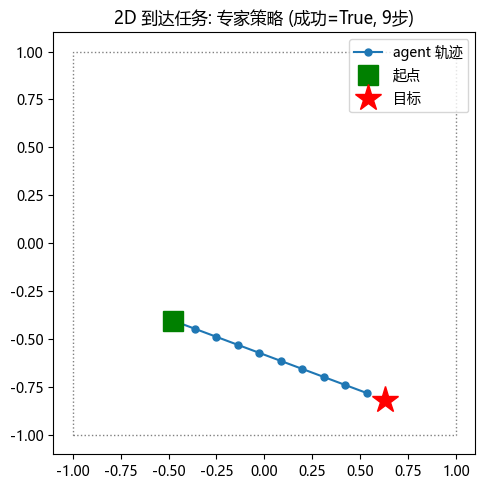

专家策略成功率 (200 episodes): 1.00


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
ok, steps, traj = env.rollout(env.expert_action, seed=2, record=True)
traj = np.array(traj)
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(traj[:,0], traj[:,1], '-o', ms=5, label='agent 轨迹')
ax.plot(traj[0,0], traj[0,1], 'gs', ms=14, label='起点')
ax.plot(traj[0,2], traj[0,3], 'r*', ms=20, label='目标')
ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
ax.legend(); ax.set_title(f'2D 到达任务: 专家策略 (成功={ok}, {steps}步)'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print(f'专家策略成功率 (200 episodes): {env.eval_policy(env.expert_action, n_episodes=200):.2f}')

## 2. tokens-as-actions: 把连续动作离散成 token

序列化: 1727 个 (state, action) → 动作 token 序列
离散化损失 (方向余弦差): 0.023 (8 方向量化的固有代价)


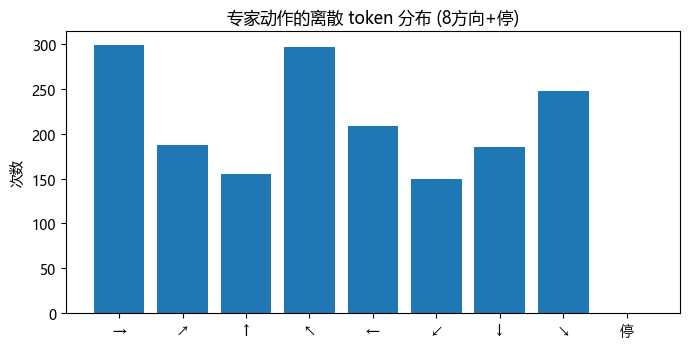

→ 动作变成了 token (像词)。于是"控制"就能当"预测下一个 token"做 (RT-2 范式, N2 验证)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
S, A = env.make_demos(n=200, seed=0)
states, toks = ser.serialize_episode(S, A)
print(f'序列化: {len(S)} 个 (state, action) → 动作 token 序列')
print(f'离散化损失 (方向余弦差): {ser.roundtrip_error(A):.3f} (8 方向量化的固有代价)')
# 动作 token 分布
fig, ax = plt.subplots(figsize=(7,3.6))
counts = np.bincount(toks, minlength=ser.N_ACTION_TOKENS)
names = ['→','↗','↑','↖','←','↙','↓','↘','停']
ax.bar(names, counts, color='C0')
ax.set_title('专家动作的离散 token 分布 (8方向+停)'); ax.set_ylabel('次数')
plt.tight_layout(); plt.show()
print('→ 动作变成了 token (像词)。于是"控制"就能当"预测下一个 token"做 (RT-2 范式, N2 验证)。')

## 3. 反思
你跑了具身的**感知-行动闭环**, 并把动作序列化成 token。带走:
- 闭环: 状态 → 策略 π → 动作 → 环境转移 → 新状态 (具身比 LLM/VLM 多的部分)。
- **tokens-as-actions**: 连续动作离散成 token, 控制就变成 token 预测 (RT-2 内核)。
- 离散化有损 (方向被量化), 是这个范式的固有代价 (推动 M11.3 扩散动作头)。
下一步 N2: 训一个 tiny transformer 做「状态→下一动作 token」预测 (具身版 next-token)。